# Kalshi `KXHMONTH` — Market Statistics, Series History & Hedging Playbook
Companion to `Model_Analysis.ipynb` (which produces the *fair* price; this notebook studies the *market* price).
**Built July 6, 2026.** Data: Kalshi public trade API v2, cached in `kalshi_data/` (set `REFRESH=True` to re-pull).

| § | Section |
|---|---------|
| 1 | Current market snapshot (June & July 2026) |
| 2 | Series history: April & May 2026 (both settled NO) — the longshot-decay pattern |
| 3 | Flow anatomy: contracts vs dollars, who is actually paying |
| 4 | Climate base rates: how often is a month "the hottest ever"? (correlation warning) |
| 5 | Microstructure: fees, spread, depth |
| 6 | The hedging & profit playbook |

In [2]:
import json, math, urllib.request, os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from collections import defaultdict

REFRESH = False
BASE = "https://api.elections.kalshi.com/trade-api/v2"
TICKERS = ["KXHMONTH-26APR","KXHMONTH-26MAY","KXHMONTH-26JUN","KXHMONTH-26JUL"]

def api(path, fname):
    p = os.path.join("kalshi_data", fname)
    if REFRESH or not os.path.exists(p):
        req = urllib.request.Request(BASE+path, headers={'User-Agent':'Mozilla/5.0'})
        open(p,'wb').write(urllib.request.urlopen(req, timeout=30).read())
    return json.load(open(p))

mkts = {t: api(f"/markets/{t}", f"market_{t}.json")['market'] for t in TICKERS}
print(f"{'ticker':<18}{'status':<10}{'result':<8}{'last':>6}{'yes bid/ask':>13}{'volume':>10}{'OI':>9}")
for t,m in mkts.items():
    print(f"{t:<18}{m['status']:<10}{m.get('result') or '-':<8}{float(m['last_price_dollars'])*100:>5.0f}c"
          f"{float(m['yes_bid_dollars'])*100:>6.0f}/{float(m['yes_ask_dollars'])*100:<3.0f}c"
          f"{float(m['volume_fp']):>12,.0f}{float(m['open_interest_fp']):>9,.0f}")
jun_close = mkts['KXHMONTH-26JUN']['expected_expiration_time']
print(f"\nJune market expected expiration: {jun_close} (NOAA June release scheduled Jul 9, 15:00 UTC)")

ticker            status    result    last  yes bid/ask    volume       OI
KXHMONTH-26APR    finalized no          1c     0/100c      63,174   30,821
KXHMONTH-26MAY    finalized no          1c     0/100c      30,627   12,334
KXHMONTH-26JUN    active    -          12c     9/12 c      87,798   31,534
KXHMONTH-26JUL    active    -          16c    14/16 c       2,294    1,781

June market expected expiration: 2026-07-08T14:00:00Z (NOAA June release scheduled Jul 9, 15:00 UTC)


## §2 · Series history — the two settled predecessors
April and May 2026 both settled **NO** (neither was a record — 2026 has tracked ~0.1 °C below 2024 all year). The pattern to learn: **YES opens at a "possibility premium" (10–30¢), decays as daily ERA5 data resolves the month, and dies at 1¢** — but the decay is *not* monotonic: it spikes on headlines. That premium is the payer of this series.

market              max YES final/now  life volume
KXHMONTH-26APR          36c        1c       63,174
KXHMONTH-26MAY          24c        1c       30,627
KXHMONTH-26JUN          28c       10c       64,776
KXHMONTH-26JUL          25c       19c        2,206

Lesson: in Apr and May, EVERY YES price above ~3c eventually went to 0 — the whole path was sell-able.
The June spike back to 9-13c AFTER the month physically ended is this series' recurring inefficiency.


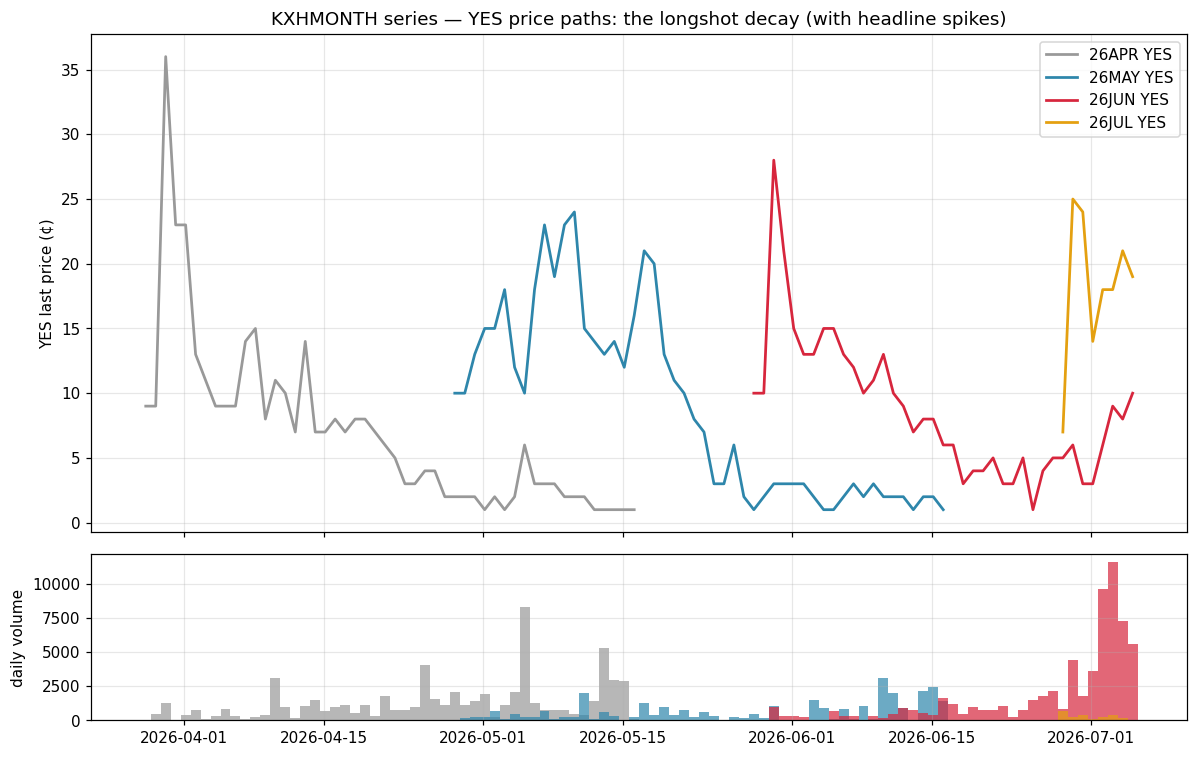

In [4]:
def candles(t):
    d = api(f"/series/KXHMONTH/markets/{t}/candlesticks?start_ts=1743465600&end_ts=1783296000&period_interval=1440",
            f"candles_{t}.json")
    out=[]
    for c in d['candlesticks']:
        px = c['price'].get('close_dollars')
        if px is None: continue
        out.append((datetime.fromtimestamp(c['end_period_ts'], tz=timezone.utc),
                    float(px), float(c.get('volume_fp') or 0), float(c.get('open_interest_fp') or 0)))
    return out

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11,7), sharex=True, height_ratios=[3,1])
cols = {'KXHMONTH-26APR':'#999','KXHMONTH-26MAY':'#2e86ab','KXHMONTH-26JUN':'#d7263d','KXHMONTH-26JUL':'#e4a010'}
stats=[]
for t in TICKERS:
    cs = candles(t)
    if not cs: continue
    dts=[c[0] for c in cs]; ys=[c[1]*100 for c in cs]; vol=[c[2] for c in cs]
    ax.plot(dts, ys, '-', lw=1.8, color=cols[t], label=f"{t[-5:]} YES")
    ax2.bar(dts, vol, color=cols[t], alpha=.7, width=1)
    stats.append((t, max(ys), ys[-1], sum(vol)))
ax.set_ylabel('YES last price (¢)'); ax.legend(); ax.grid(alpha=.3)
ax.set_title('KXHMONTH series — YES price paths: the longshot decay (with headline spikes)')
ax2.set_ylabel('daily volume'); ax2.grid(alpha=.3)
plt.tight_layout()
print(f"{'market':<18}{'max YES':>9}{'final/now':>10}{'life volume':>13}")
for t,mx,last,v in stats: print(f"{t:<18}{mx:>8.0f}c{last:>9.0f}c{v:>13,.0f}")
print("\nLesson: in Apr and May, EVERY YES price above ~3c eventually went to 0 — the whole path was sell-able.")
print("The June spike back to 9-13c AFTER the month physically ended is this series' recurring inefficiency.")

## §3 · Flow anatomy — contracts are not conviction
Order books rank by **contracts**, but information is carried by **dollars at risk**. A 1,000-contract YES lift at 10¢ risks \$100; a 400-contract NO lift at 88¢ risks \$352. On Kalshi, an NO holder *selling out* also prints as a YES-side take — squeezes masquerade as demand. Decomposing the June tape:

day          YES contracts YES $risk  NO contracts  NO $risk
2026-07-03           3,474      344$         2,058    1,882$
2026-07-04           4,155      405$         2,293    2,099$
2026-07-05           5,524      606$         6,823    6,241$
2026-07-06           5,878      712$         5,171    4,646$

Reading: the side moving the price (YES) risks a fraction of the dollars the NO side quietly deploys.


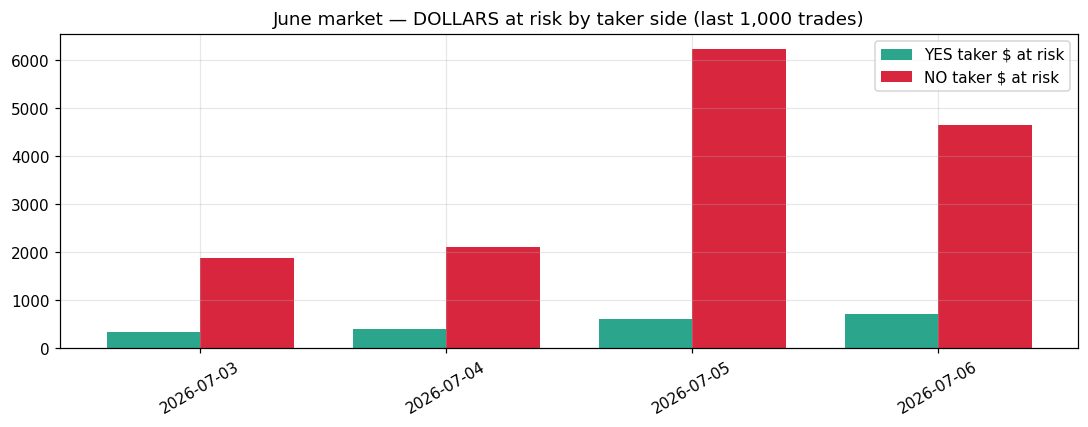

In [6]:
tr = api("/markets/trades?ticker=KXHMONTH-26JUN&limit=1000", "trades_KXHMONTH-26JUN.json")['trades']
agg_n = defaultdict(float); agg_d = defaultdict(float)
for x in tr:
    day = x['created_time'][:10]; side = x['taker_side']
    n = float(x.get('count_fp') or x.get('count') or 0); px = float(x.get('yes_price_dollars') or 0)
    agg_n[(day,side)] += n
    agg_d[(day,side)] += n*(px if side=='yes' else 1-px)
days = sorted({k[0] for k in agg_n})
print(f"{'day':<12}{'YES contracts':>14}{'YES $risk':>10}{'NO contracts':>14}{'NO $risk':>10}")
for d in days:
    print(f"{d:<12}{agg_n.get((d,'yes'),0):>14,.0f}{agg_d.get((d,'yes'),0):>9,.0f}$"
          f"{agg_n.get((d,'no'),0):>14,.0f}{agg_d.get((d,'no'),0):>9,.0f}$")
fig, ax = plt.subplots(figsize=(10,4))
x = np.arange(len(days)); w=.38
ax.bar(x-w/2, [agg_d.get((d,'yes'),0) for d in days], w, color='#2ca58d', label='YES taker $ at risk')
ax.bar(x+w/2, [agg_d.get((d,'no'),0) for d in days], w, color='#d7263d', label='NO taker $ at risk')
ax.set_xticks(x); ax.set_xticklabels(days, rotation=30); ax.legend(); ax.grid(alpha=.3)
ax.set_title('June market — DOLLARS at risk by taker side (last 1,000 trades)')
plt.tight_layout()
print("\nReading: the side moving the price (YES) risks a fraction of the dollars the NO side quietly deploys.")

## §4 · Climate base rates — how often does *any* month set a record?
From NOAA's full 12-month history: for each year and month, did that month beat all predecessors? Two facts drive strategy:
1. Record months are **rare in trend-only years** but **cluster violently** in El Niño onset/peak windows (NOAA logged a streak of ~13 consecutive record months across 2023–24).
2. Therefore NO positions across consecutive months are **highly correlated** — a burst regime wipes out a "sell every month" book all at once. This is the single most important risk fact for this series, with a **very strong El Niño now forecast for late 2026 (63% chance, CPC)**.

Record months 2015–2025: 42 of 132 month-slots = base rate 32%
...but distribution: {2015: 8, 2016: 8, 2019: 5, 2020: 6, 2023: 7, 2024: 6, 2025: 2}
Burst years (2015/16, 2023/24) hold nearly all of them -> tail correlation across consecutive months is EXTREME.


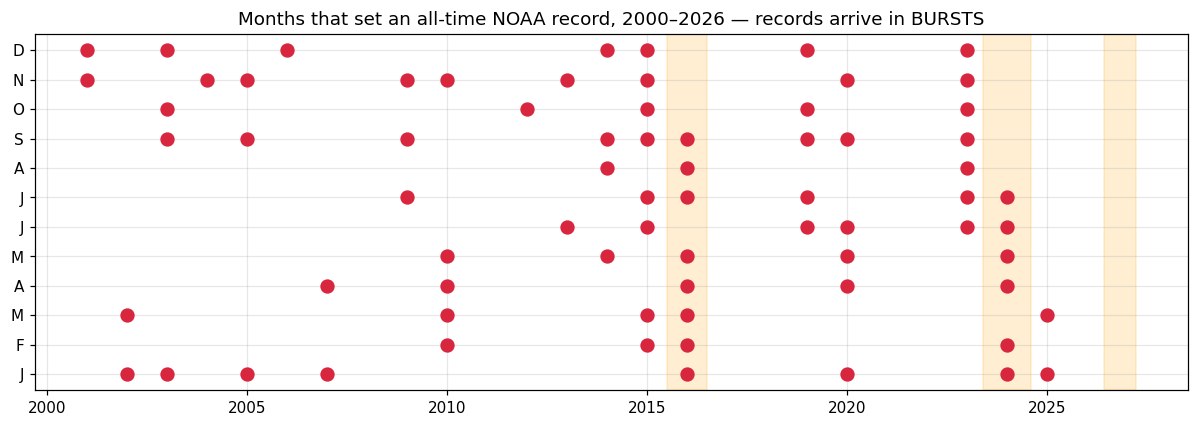

In [8]:
NOAA_URL = "https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/global/time-series/globe/land_ocean/1/{m}/1850-2026/data.json"
def noaa_series(m):
    p=f"noaa_m{m}.json"
    if REFRESH or not os.path.exists(p):
        req=urllib.request.Request(NOAA_URL.format(m=m), headers={'User-Agent':'Mozilla/5.0'})
        open(p,'wb').write(urllib.request.urlopen(req, timeout=60).read())
    return {int(k):v['departure'] for k,v in json.load(open(p))['data'].items()}

records = []   # (year, month) that set a record at the time
for m in range(1,13):
    s = noaa_series(m)
    best = -9
    for y in sorted(s):
        if s[y] > best:
            if y >= 1990: records.append((y,m))
            best = s[y]
rec_recent = [(y,m) for y,m in records if y >= 2000]
fig, ax = plt.subplots(figsize=(11,4))
ax.scatter([y for y,_ in rec_recent],[m for _,m in rec_recent], s=70, color='#d7263d', zorder=3)
for y0,y1,lab in [(2015.5,2016.5,'El Niño 15/16'),(2023.4,2024.6,'El Niño 23/24'),(2026.4,2027.2,'El Niño 26/27 ??')]:
    ax.axvspan(y0,y1,color='orange',alpha=.18); ax.annotate(lab,(y0, 12.6), fontsize=8, color='#b8860b')
ax.set_yticks(range(1,13)); ax.set_yticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_title('Months that set an all-time NOAA record, 2000–2026 — records arrive in BURSTS')
ax.grid(alpha=.3); plt.tight_layout()
per_yr = defaultdict(int)
for y,m in records: per_yr[y]+=1
n_rec_15_25 = sum(1 for y,m in records if 2015<=y<=2025)
print(f"Record months 2015–2025: {n_rec_15_25} of 132 month-slots = base rate {n_rec_15_25/132*100:.0f}%")
print(f"...but distribution: {dict(sorted((y,c) for y,c in per_yr.items() if y>=2015))}")
print("Burst years (2015/16, 2023/24) hold nearly all of them -> tail correlation across consecutive months is EXTREME.")

## §5 · Microstructure — fees, spread, depth
Kalshi taker fee ≈ $0.07\cdot P\cdot(1-P)$ per contract (max ~1.75¢ at P=50¢; ~0.5¢ at 90¢). The real constraint in this series is **depth**: cents-wide books with a few hundred to ~1,700 contracts per level. Entering or exiting more than ~\$1–2k moves the price multiple cents — size accordingly, use limit orders at mid.

Fee curve: 0.07*P*(1-P) -> at 10c: 0.63c | 50c: 1.75c | 90c: 0.63c per contract
Total resting liquidity within 10 levels: NO side $2,464 | YES side $275  <- this is a SMALL market


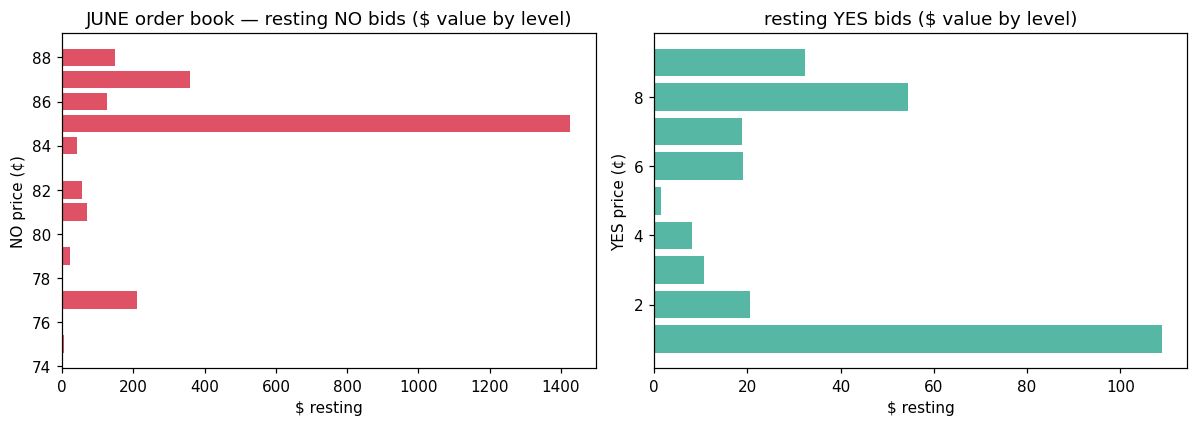

In [10]:
ob = api("/markets/KXHMONTH-26JUN/orderbook?depth=10", "orderbook_KXHMONTH-26JUN.json")['orderbook_fp']
fig, axes = plt.subplots(1, 2, figsize=(11,4))
no_lv  = [(float(p)*100, float(q)) for p,q in ob.get('no_dollars',[])]
yes_lv = [(float(p)*100, float(q)) for p,q in ob.get('yes_dollars',[])]
axes[0].barh([p for p,_ in no_lv],[q*(p/100) for p,q in no_lv], color='#d7263d', alpha=.8)
axes[0].set_title('JUNE order book — resting NO bids ($ value by level)'); axes[0].set_ylabel('NO price (¢)'); axes[0].set_xlabel('$ resting')
axes[1].barh([p for p,_ in yes_lv],[q*(p/100) for p,q in yes_lv], color='#2ca58d', alpha=.8)
axes[1].set_title('resting YES bids ($ value by level)'); axes[1].set_ylabel('YES price (¢)'); axes[1].set_xlabel('$ resting')
plt.tight_layout()
ps = np.linspace(0.01,0.99,99)
print("Fee curve: 0.07*P*(1-P) -> at 10c: {:.2f}c | 50c: {:.2f}c | 90c: {:.2f}c per contract".format(
    7*.1*.9, 7*.5*.5, 7*.9*.1))
tot_no = sum(q*(p/100) for p,q in no_lv); tot_yes = sum(q*(p/100) for p,q in yes_lv)
print(f"Total resting liquidity within 10 levels: NO side ${tot_no:,.0f} | YES side ${tot_yes:,.0f}  <- this is a SMALL market")

## §6 · The hedging & profit playbook

**Where the edge comes from (and when):** the ERA5→NOAA publication gap. The market's persistent errors, in order of exploitability —
1. **Post-month, pre-print window** (days 1–9 of the next month): the outcome is physically fixed, translation model prices it, retail still trades headlines. *This is the prime window — the June NO trade.*
2. **Headline spikes:** CPC/ENSO announcements and regional heatwave records move the *global-mean* market even when irrelevant to it (Jun 11 advisory spike to 18¢; Jul 2–4 spike after European records). Fade them — with limits, not market orders.
3. **Day-15 / Day-26 variance collapses:** σ halves then quarters while spreads barely move. Re-run the model on those dates; trade only if |fair − market| > 5¢ + fees.

**The five risk rules:**
1. **Correlation cap.** Consecutive-month NOs share one climate state. Cap *aggregate* NO exposure across all open months at what you'd risk on ONE month. In El Niño onset years (now), assume all NOs can lose together.
2. **Regime flip is coming (Q4 2026).** With a 63%-probability very-strong El Niño peaking Nov–Jan, late-2026 months are *genuine* record candidates (base-rate bursts, §4). The NO habit that pays Apr–Sep gets destroyed Nov–Jan. If Nov/Dec YES trades at Apr-like levels (≤15¢), the *value flips to YES*.
3. **Basis hedge via Polymarket.** Polymarket's rank-bracket market settles on NASA GISTEMP (ties count *into* brackets). Holding large Kalshi NO, you can buy Polymarket "1st hottest" YES as disaster insurance: the datasets agree on clear records (~90%+ of the time), so it pays precisely in the worlds that kill your NO. Price the hedge vs the σ-normalized gap — NOAA's record is usually the "softer" of the two (lower Z), so Kalshi YES *should* trade richer than Polymarket 1st; only hedge when the premium is < the model's tail.
4. **Tie discount.** Kalshi's rules have no tie clause. Within one tick of the record, haircut NO fair value by ~1–2¢ for review risk.
5. **Liquidity discipline.** Never market-order through >2 levels; assume you cannot exit >$1k without 2–3¢ slippage; the fee round-trip at 90¢ is ~1¢ — an edge under 3¢ is not tradeable here.

**Catalyst calendar:** Jul 9 15:00 UTC — NOAA June print (June settles) · Jul 7–8 — Nick Stokes TempLS June estimate (moyhu.blogspot.com; a NOAA-method replication: if it shows June 2026 ≥ June 2024, exit June NO immediately) · Jul 17–18 — day-15 checkpoint · Jul 28 — day-26 checkpoint · ~Aug 13 — July print.

In [12]:
# ---- Position calculator ----------------------------------------------------------
def position(bankroll, no_ask, p_yes, kelly_frac=0.25, depth_dollars=1500):
    p_no = 1 - p_yes
    fee = 0.07*no_ask*(1-no_ask)
    ev = p_no - no_ask - fee
    b = (1-no_ask)/no_ask
    f = max(0.0, (p_no*(1+b)-1)/b) * kelly_frac
    dollars = min(bankroll*f, depth_dollars)
    n = int(dollars/no_ask)
    print(f"NO @ {no_ask*100:.0f}c, P(YES)={p_yes*100:.1f}%  ->  EV {ev*100:+.1f}c/contract | "
          f"{kelly_frac:.0%}-Kelly = {f*100:.1f}% of bankroll -> {n} contracts (${n*no_ask:,.0f}), "
          f"max loss ${n*no_ask:,.0f}, exp. profit ${n*ev:,.0f}")
print("Examples (bankroll $5,000):")
position(5000, 0.88, 0.05)     # June central scenario at current ask
position(5000, 0.88, 0.08)     # June pessimistic
position(5000, 0.84, 0.24)     # July at current ask, audit-adjusted central -> negative EV = no trade
print("\nRule of thumb: trade only when EV > +3c after fees; otherwise the spread/slippage eats it.")

Examples (bankroll $5,000):
NO @ 88c, P(YES)=5.0%  ->  EV +6.3c/contract | 25%-Kelly = 14.6% of bankroll -> 828 contracts ($729), max loss $729, exp. profit $52
NO @ 88c, P(YES)=8.0%  ->  EV +3.3c/contract | 25%-Kelly = 8.3% of bankroll -> 473 contracts ($416), max loss $416, exp. profit $15
NO @ 84c, P(YES)=24.0%  ->  EV -8.9c/contract | 25%-Kelly = 0.0% of bankroll -> 0 contracts ($0), max loss $0, exp. profit $-0

Rule of thumb: trade only when EV > +3c after fees; otherwise the spread/slippage eats it.
